In [ ]:
!pip install tensorflow requests -q


[notice] A new release of pip is available: 23.2.1 -> 25.1
[notice] To update, run: pip install --upgrade pip


Loading category: Face
  Success: https://images.pexels.com/photos/774909/pexels-photo-774909.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1
  Success: https://images.pexels.com/photos/1043471/pexels-photo-1043471.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1
  Success: https://images.pexels.com/photos/91227/pexels-photo-91227.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1
Loading category: Car
  Success: https://images.pexels.com/photos/112460/pexels-photo-112460.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1
  Success: https://images.pexels.com/photos/170811/pexels-photo-170811.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1
  Success: https://images.pexels.com/photos/707046/pexels-photo-707046.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1
Loading category: Flower
  Success: https://images.pexels.com/photos/36729/tulip-flower-bloom-pink.jpg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1
  Success: https://images.pexels.com/photos/132474/pexels-photo-132474.jpeg?auto=

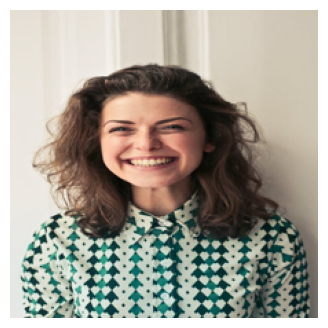

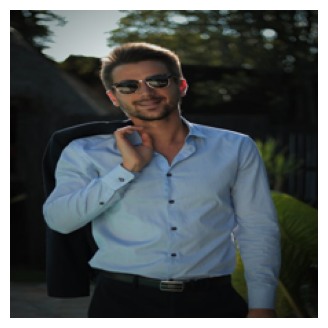

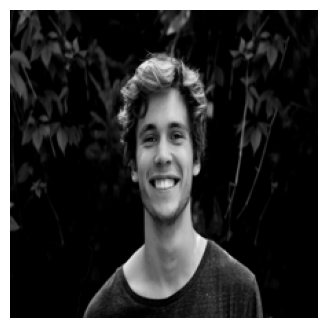

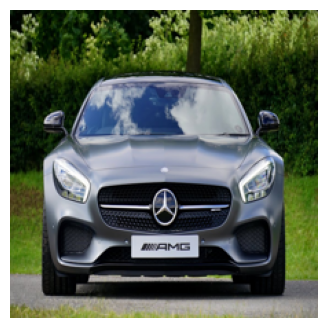

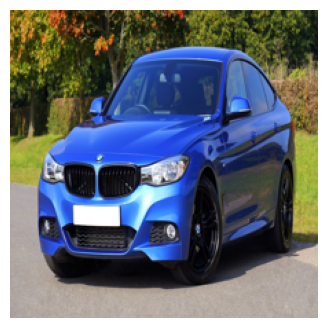

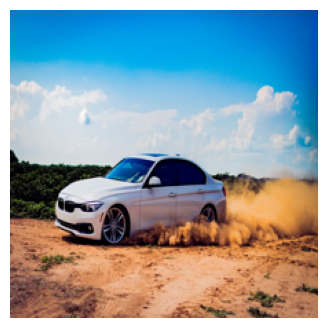

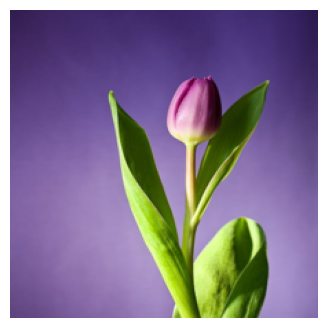

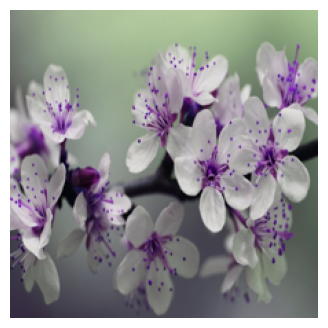

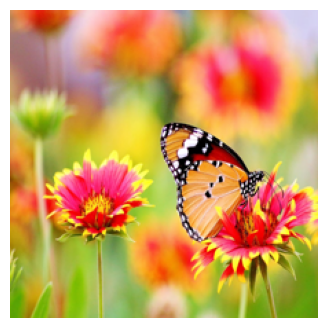


Loading MobileNetV3-Small and preparing intermediate models...
 - Layer (Early) model created using layer 'expanded_conv_project_bn'
 - Layer (Mid) model created using layer 'expanded_conv_5_project_bn'
 - Layer (Late) model created using layer 'expanded_conv_10_project_bn'

Extracting features and calculating similarities...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
 - Extracted features for Layer (Early), shape: (9, 16)
 - Cosine similarity matrix calculated for Layer (Early), shape: (9, 9)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 733ms/step
 - Extracted features for Layer (Mid), shape: (9, 40)
 - Cosine similarity matrix calculated for Layer (Mid), shape: (9, 9)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
 - Extracted features for Layer (Late), shape: (9, 96)
 - Cosine similarity matrix calculated for Layer (Late), shape: (9, 9)

Generating vertical similarity axis plots (separate figure for each layer)...


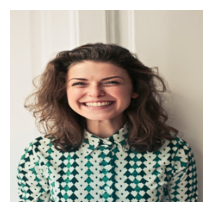

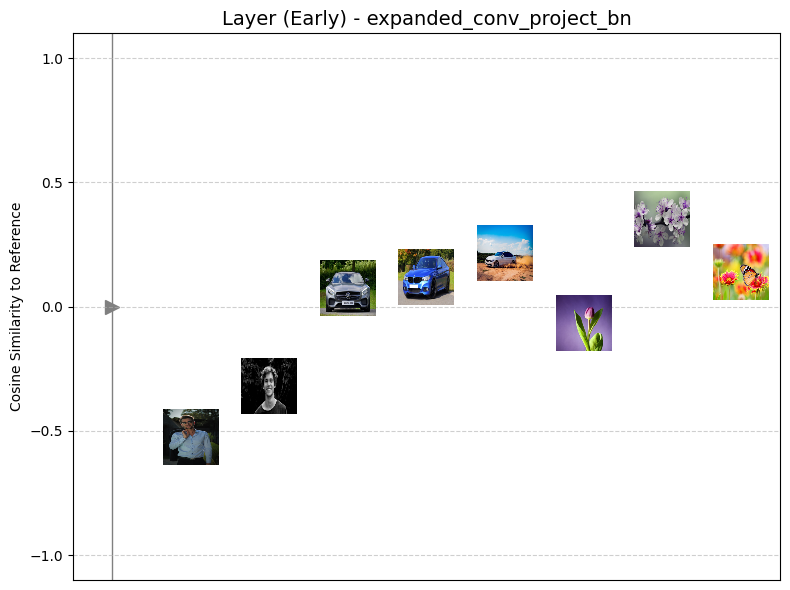

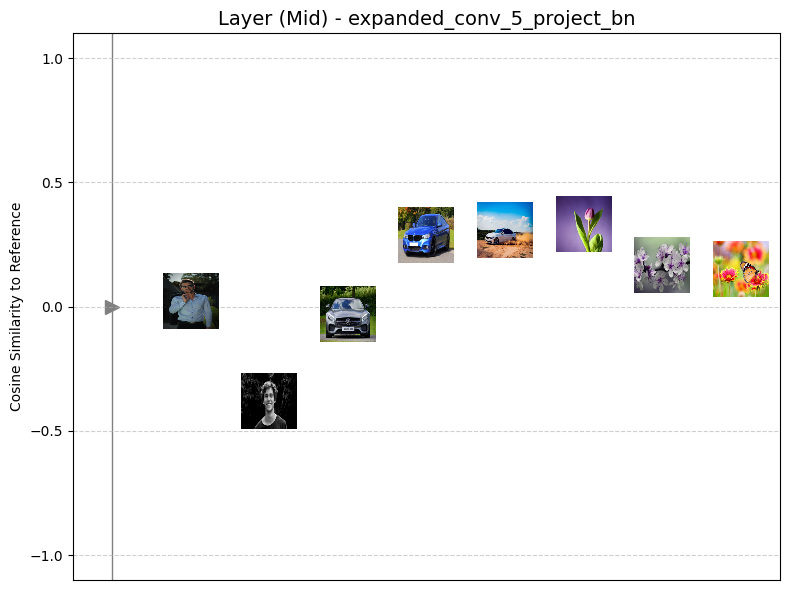

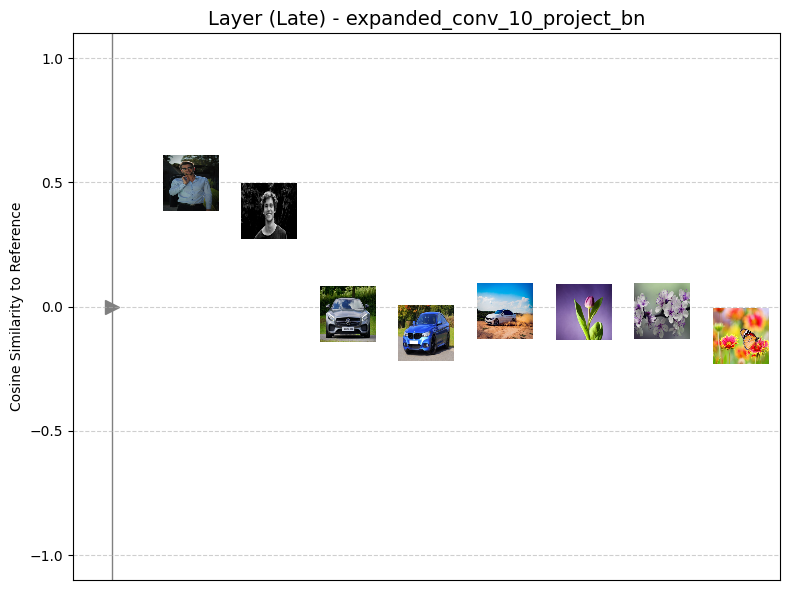


Visualization complete.


In [ ]:
# -*- coding: utf-8 -*-
"""
基準画像との類似度に基づく画像配置デモ（縦軸・個別Figure版）

少数の画像（顔、車、花）を使い、MobileNetV3-Smallの
初期・中間・最終層での特徴ベクトルを抽出。
最初の画像（基準画像）と他の画像とのコサイン類似度を計算し、
その類似度スコアを縦軸に対応させて画像を配置。
各レイヤーの結果を個別のFigureに表示します。
"""

# --- 0. ライブラリのインストール & インポート ---
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from matplotlib.offsetbox import OffsetImage, AnnotationBbox # 画像をプロット上に配置するために必要

# --- 1. パラメータ設定 ---
# (前回と同じ)
img_height, img_width = 224, 224
image_urls = {
    'Face': [
        "https://images.pexels.com/photos/774909/pexels-photo-774909.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1",
        "https://images.pexels.com/photos/1043471/pexels-photo-1043471.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1",
        "https://images.pexels.com/photos/91227/pexels-photo-91227.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1"
    ], 'Car': [
        "https://images.pexels.com/photos/112460/pexels-photo-112460.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1",
        "https://images.pexels.com/photos/170811/pexels-photo-170811.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1",
        "https://images.pexels.com/photos/707046/pexels-photo-707046.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1"
    ], 'Flower': [
        "https://images.pexels.com/photos/36729/tulip-flower-bloom-pink.jpg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1",
        "https://images.pexels.com/photos/132474/pexels-photo-132474.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1",
        "https://images.pexels.com/photos/462118/pexels-photo-462118.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1"
    ]
}
# ★用語変更 & 辞書キーも変更★
layer_names = {
    'Early': 'expanded_conv_project_bn',
    'Mid':   'expanded_conv_5_project_bn',
    'Late':  'expanded_conv_10_project_bn'
}
layer_keys_in_order = ['Early', 'Mid', 'Late'] # 処理と表示の順序を定義
category_order = ['Face', 'Car', 'Flower']
# カテゴリの色分け (線用)
category_colors = {
    'Face': 'red',
    'Car': 'blue',
    'Flower': 'green'
}

# --- 2. 画像の準備 ---
# (前回と同じ)
print("Downloading and preprocessing images...")
input_images_preprocessed = []
original_images_for_display = []
labels = []
category_counts = {cat: 0 for cat in category_order}
current_index = 0
for category in category_order:
    urls = image_urls[category]
    print(f"Loading category: {category}")
    for url in urls:
        try:
            headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
            response = requests.get(url, headers=headers, timeout=10); response.raise_for_status()
            img = Image.open(BytesIO(response.content)).convert('RGB')
            img_resized = img.resize((img_width, img_height))
            original_images_for_display.append(img_resized)
            img_array = tf.keras.preprocessing.image.img_to_array(img_resized)
            img_array_expanded = np.expand_dims(img_array, axis=0)
            img_preprocessed = preprocess_input(img_array_expanded)
            input_images_preprocessed.append(img_preprocessed)
            labels.append(category)
            category_counts[category] += 1
            current_index += 1
            print(f"  Success: {url}")
        except requests.exceptions.RequestException as e: print(f"  Warning: Failed to load image {url}: {e}")
        except Exception as e: print(f"  Warning: Error processing image {url}: {e}")
if not input_images_preprocessed: raise ValueError("No images loaded.")
input_images = np.vstack(input_images_preprocessed)
num_total_images = len(labels)
print(f"\n{num_total_images} images loaded successfully in total.")
print("Category counts:", category_counts)

# Display all loaded images individually
print("\nDisplaying all loaded images...")
for idx, (img, label) in enumerate(zip(original_images_for_display, labels)):
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(img)
    # ax.set_title(f"Image {idx}: {label}")
    ax.axis('off')
    plt.show()

# --- 3. モデルのロードと中間層モデルの準備 ---
print("\nLoading MobileNetV3-Small and preparing intermediate models...")
try:
    base_model = MobileNetV3Small(input_shape=(img_height, img_width, 3), weights='imagenet', include_top=False)
    intermediate_models = {}
    verified_layer_names = {}
    actual_layers = {layer.name: layer for layer in base_model.layers}
    # ★layer_keys_in_order を使用★
    for layer_key in layer_keys_in_order:
        name = layer_names[layer_key]
        if name in actual_layers:
            layer_output = actual_layers[name].output
            pooled_output = GlobalAveragePooling2D()(layer_output)
            intermediate_models[layer_key] = Model(inputs=base_model.input, outputs=pooled_output)
            verified_layer_names[layer_key] = name
            print(f" - Layer ({layer_key}) model created using layer '{name}'")
        else: print(f" - Warning: Layer '{name}' for Layer ({layer_key}) not found. Skipping.")
    if not intermediate_models: raise ValueError("No valid intermediate models created.")
except Exception as e: print(f"Error loading model: {e}"); raise

# --- 4. 特徴抽出とコサイン類似度計算 ---
print("\nExtracting features and calculating similarities...")
similarity_matrices = {}
layers_processed = [] # 実際に処理できたレイヤーキー

# ★layer_keys_in_order を使用★
for layer_key in layer_keys_in_order:
    if layer_key in intermediate_models:
        model = intermediate_models[layer_key]
        layers_processed.append(layer_key)
        tf.get_logger().setLevel('ERROR'); features = model.predict(input_images); tf.get_logger().setLevel('WARNING')
        print(f" - Extracted features for Layer ({layer_key}), shape: {features.shape}")
        similarity_matrix = cosine_similarity(features)
        similarity_matrices[layer_key] = similarity_matrix
        print(f" - Cosine similarity matrix calculated for Layer ({layer_key}), shape: {similarity_matrix.shape}")

# --- 5. ★★★ 新しい可視化：類似度（縦軸）に基づいた画像配置（個別Figure版）★★★ ---
print("\nGenerating vertical similarity axis plots (separate figure for each layer)...")

num_layers_processed = len(layers_processed)
actual_num_images = num_total_images

if num_layers_processed > 0 and actual_num_images > 0:

    reference_image_index = 0
    reference_image = original_images_for_display[reference_image_index]
    reference_label = labels[reference_image_index]

    # 基準画像を最初に一度だけ表示
    fig_ref, ax_ref = plt.subplots(1, 1, figsize=(2.5, 2.5))
    ax_ref.imshow(reference_image)
    # ax_ref.set_title(f"Reference Image\n(Index 0: {reference_label})")
    ax_ref.axis('off')
    plt.show() # 基準画像を表示

    # 各レイヤーごとに個別のFigureを作成
    for layer_key in layers_processed: # Early, Mid, Late の順
        if layer_key in similarity_matrices:

            # ★新しいFigureを作成★
            fig_sim_axis_v, ax = plt.subplots(1, 1, figsize=(8, 6)) # 各レイヤーに1つのAxes

            similarities_to_first = similarity_matrices[layer_key][reference_image_index, :]

            # 縦軸（類似度軸）を描画
            ax.axvline(0, color='gray', linestyle='-', linewidth=1, zorder=0) # zorderで背面に
            ax.plot([0], [0], '>', color='gray', markersize=10, zorder=1) # 0の位置を示すマーカー
            ax.set_ylim(-1.1, 1.1)
            # X軸の範囲を調整 (画像の数とサムネイルサイズに基づく)
            ax.set_xlim(-0.5, actual_num_images - 0.5)
            ax.set_xticks([]) # X軸の目盛りは不要
            ax.set_yticks([-1.0, -0.5, 0, 0.5, 1.0])
            ax.set_ylabel("Cosine Similarity to Reference")
            ax.grid(True, axis='y', linestyle='--', alpha=0.6)
            # ★タイトル変更★
            ax.set_title(f"Layer ({layer_key}) - {verified_layer_names[layer_key].split('/')[-1]}", fontsize=14)

            # 各画像（基準画像を除く）を類似度スコアの高さに配置
            thumbnail_zoom = 0.18 # サムネイルのサイズ調整用
            x_pos_counter = 1 # 画像を水平方向に配置するためのカウンター

            for i in range(actual_num_images):
                if i == reference_image_index: continue # 基準画像はプロットしない

                score = similarities_to_first[i]
                img_pil = original_images_for_display[i]
                img_array = np.array(img_pil) # NumPy配列に変換
                label = labels[i]
                color = category_colors.get(label, 'gray') # カテゴリ色取得

                # X座標を決定（単純にインデックスを使う）
                x_pos = x_pos_counter
                x_pos_counter += 1

                # 画像を配置
                imagebox = OffsetImage(img_array, zoom=thumbnail_zoom)
                imagebox.image.axes = ax
                ab = AnnotationBbox(imagebox, (x_pos, score),
                                    xybox=(0., 0.), # オフセットなし
                                    frameon=False, # ★枠線を削除★
                                    # bboxprops=dict(edgecolor=color, lw=1.5), # 枠線削除
                                    xycoords='data',
                                    boxcoords="offset points",
                                    pad=0.1,
                                    arrowprops=dict(arrowstyle="-", color=color, alpha=0.6, shrinkA=5, shrinkB=5), # 縦軸への線, shrinkで画像に重ならないように
                                    zorder=2 # 線やマーカーより前面に
                                    )
                ax.add_artist(ab)

                # ラベルを画像の近くに表示（オプション）
                # ax.text(x_pos, score + thumbnail_zoom * 0.6, f"{label[:1]}{category_counts[label]}", ha='center', va='bottom', fontsize=8, color=color)


            # ★ループの外で plt.show() を呼び出し、Figureを個別に表示★
            plt.tight_layout()
            plt.show()

else:
    print("\nSkipping vertical similarity axis plot as no layers were processed or no images were loaded.")


print("\nVisualization complete.")

TensorFlow version: 2.18.0
学習済みモデル(MobileNetV3Small)をロード中...
モデルのロード完了。

--- 最適入力画像の生成（各層が何に強く反応するか） ---
一時モデルの作成または重みロードに失敗: URL fetch failure on https://storage.googleapis.com/tensorflow/keras-applications/mobilenet_v3/weights_mobilenet_v3_small_224_0.5_minimalistic_no_top.h5: 404 -- Not Found
一時モデルの準備に失敗したため、最適入力画像の生成をスキップします。

--- 単純図形に対する活性化マップ（各層がどこに注目するか） ---

入力画像: 縦線


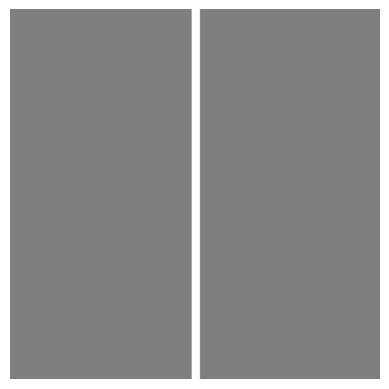

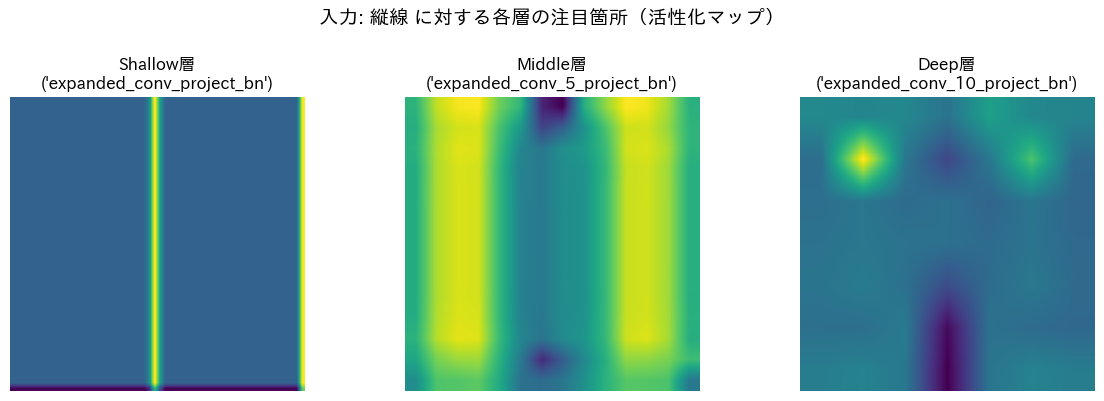


入力画像: 横線


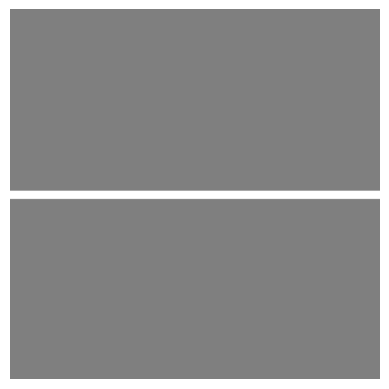

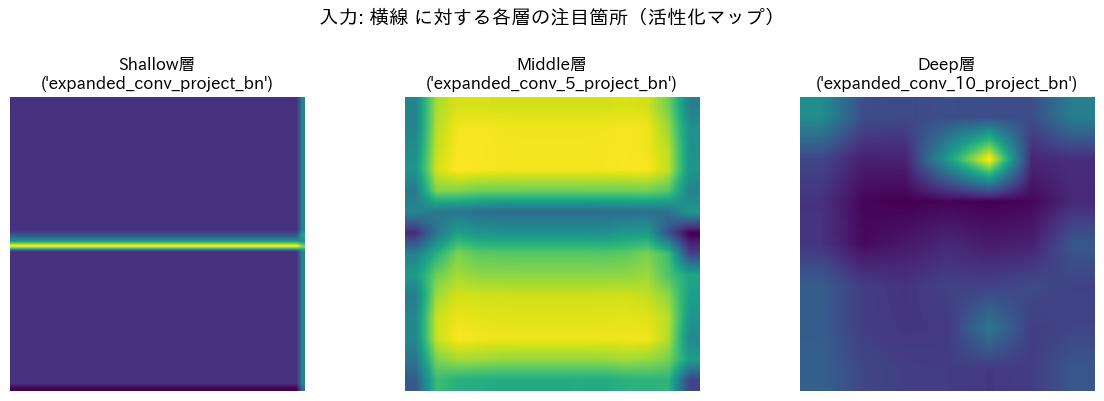


入力画像: 円


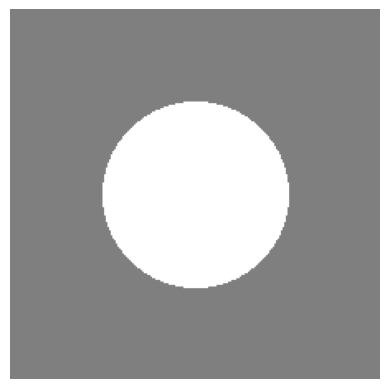

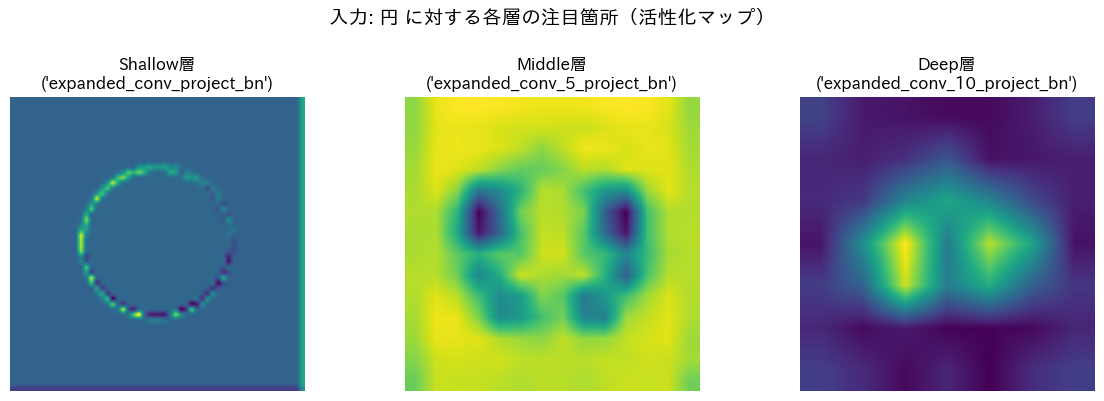


入力画像: 赤パッチ


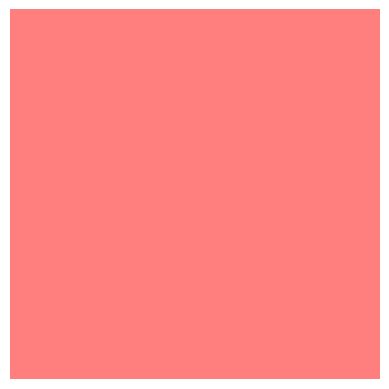

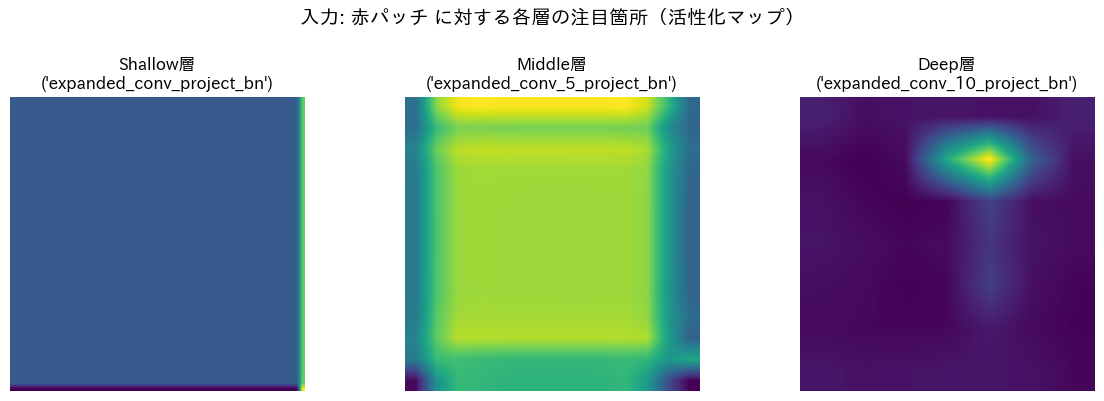


可視化完了。


In [5]:
# -*- coding: utf-8 -*-
# --- 0. ライブラリのインストール & インポート ---
# 日本語表示に必要なライブラリをインストール
!pip install japanize-matplotlib

# 必要なライブラリをインポートします
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import requests
from io import BytesIO
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.models import Model
import japanize_matplotlib # Matplotlibの日本語化
import math

print(f"TensorFlow version: {tf.__version__}")

# --- 1. モデルのロードと層の選択 ---
print("学習済みモデル(MobileNetV3Small)をロード中...")
# include_top=Falseで、最後の分類部分を除いた構造を読み込みます
base_model = MobileNetV3Small(input_shape=(224, 224, 3), weights='imagenet', include_top=False)
print("モデルのロード完了。")

# 可視化対象とする層の名前を選びます
# ★ エラーログに基づき、存在するレイヤー名に修正 ★
layer_names_to_visualize = {
    'Shallow': 'expanded_conv_project_bn',     # 最初のブロックの project 層の BatchNorm
    'Middle':  'expanded_conv_5_project_bn',   # 5番目のブロックの project 層の BatchNorm
    'Deep':    'expanded_conv_10_project_bn'   # 10番目のブロックの project 層の BatchNorm
    # 'Final_Conv': 'conv_1'                   # 最後の畳み込み層 (Global Pooling前) # 必要に応じて変更
}
layer_keys_in_order = ['Shallow', 'Middle', 'Deep'] # この順番で表示

# モデルの層構造を確認 (デバッグ用にコメント解除)
# print("\n--- Base Model Layers ---")
# for layer in base_model.layers:
#     print(layer.name)
# print("-" * 20)

# --- 2. ヘルパー関数 ---

# 画像表示用の関数 (変更なし)
def display_image(image_array, title=None):
    img_display = (image_array.astype(np.float32) + 1.0) / 2.0
    img_display = np.clip(img_display, 0, 1)
    plt.imshow(img_display)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

# 最適入力画像生成のための関数 (基本的な勾配上昇法)
@tf.function
def gradient_ascent_step(model, img_tensor, layer_name, channel_index=None, learning_rate=1.0):
    """1ステップ分の勾配上昇計算"""
    try:
        intermediate_model = Model(inputs=model.input, outputs=model.get_layer(layer_name).output)
    except ValueError as e:
        print(f"Error creating intermediate model for layer '{layer_name}': {e}")
        # エラー発生時は勾配をゼロとして返し、更新をスキップ
        return img_tensor

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        layer_output = intermediate_model(img_tensor)
        if layer_output is None: # 中間モデル作成失敗時
             return img_tensor
        if channel_index is not None:
            # チャネルインデックスが範囲外でないか確認
            if channel_index >= layer_output.shape[-1]:
                print(f"Warning: channel_index {channel_index} is out of bounds for layer {layer_name} with shape {layer_output.shape}. Using channel 0 instead.")
                channel_index = 0
            activation_target = tf.reduce_mean(layer_output[:, :, :, channel_index])
        else:
            activation_target = tf.norm(layer_output)

    grads = tape.gradient(activation_target, img_tensor)
    # gradsがNoneになるケース（勾配計算失敗など）への対応
    if grads is None:
        print(f"Warning: Could not compute gradient for layer {layer_name}. Skipping update.")
        return img_tensor
    grads /= (tf.sqrt(tf.reduce_mean(tf.square(grads))) + 1e-5)
    img_tensor.assign_add(grads * learning_rate)
    return img_tensor

def generate_optimal_input(model, layer_name, channel_index=None,
                           img_size=(224, 224), steps=100, learning_rate=1.0,
                           initial_img=None, apply_blur_every=0):
    """指定した層/チャネルの活性化を最大にする画像を生成"""
    if initial_img is None:
        img_array = np.random.uniform(low=-0.1, high=0.1, size=(1, img_size[0], img_size[1], 3)) + 0.5
    else:
        img_array = initial_img.copy()

    img_tensor = tf.Variable(img_array, dtype=tf.float32)

    print(f"  Optimizing for layer: {layer_name}...") # 最適化対象のレイヤー名表示

    for step in range(steps):
        img_tensor = gradient_ascent_step(model, img_tensor, layer_name, channel_index, learning_rate)
        img_tensor.assign(tf.clip_by_value(img_tensor, -1.0, 1.0))
        if (step + 1) % (steps // 5) == 0 or step == 0: # 進捗表示を少し詳細に
            print(f"    Step {step + 1}/{steps}")

    return img_tensor.numpy()[0]

# 単純図形生成関数 (変更なし)
def create_simple_shape_image(shape_type='line', size=(224, 224), color=(255, 255, 255), bgcolor=(0, 0, 0)):
    # (内容は変更なし)
    img = Image.new('RGB', size, bgcolor)
    draw = ImageDraw.Draw(img)
    center_x, center_y = size[0] // 2, size[1] // 2
    line_width = max(1, size[0] // 40)
    radius = size[0] // 4
    if shape_type == 'vertical_line':
        draw.line([(center_x, 0), (center_x, size[1])], fill=color, width=line_width)
        title = "縦線"
    elif shape_type == 'horizontal_line':
        draw.line([(0, center_y), (size[0], center_y)], fill=color, width=line_width)
        title = "横線"
    elif shape_type == 'diagonal_line':
        draw.line([(0, 0), (size[0], size[1])], fill=color, width=line_width)
        title = "斜線"
    elif shape_type == 'circle':
        draw.ellipse([(center_x - radius, center_y - radius), (center_x + radius, center_y + radius)], fill=color)
        title = "円"
    elif shape_type == 'red_patch':
        img = Image.new('RGB', size, (255, 0, 0))
        title = "赤パッチ"
    else:
        title = "無地"
    return np.array(img), title

# 活性化マップ可視化関数
def visualize_activation_map(model, layer_name, input_image_np, title="活性化マップ"):
    """指定した層の活性化マップを可視化する"""
    img_preprocessed = preprocess_input(np.expand_dims(input_image_np.astype(np.float32), axis=0))
    try:
        # ★ 中間モデル作成を関数内に移動 ★
        intermediate_model = Model(inputs=model.input, outputs=model.get_layer(layer_name).output)
        layer_output = intermediate_model.predict(img_preprocessed, verbose=0)[0] # verbose=0 でログ抑制
        activation_map = np.mean(layer_output, axis=-1)
        activation_map_resized = tf.image.resize(np.expand_dims(activation_map, axis=-1),
                                                  [input_image_np.shape[0], input_image_np.shape[1]]).numpy()[:,:,0]
        plt.imshow(activation_map_resized, cmap='viridis')
        plt.title(title)
        plt.axis('off')
        # plt.colorbar() # カラーバーは表示するとレイアウトが崩れる場合があるので一旦コメントアウト

    except ValueError as e:
        print(f"  層 '{layer_name}' の活性化マップ生成に失敗: {e}")
        plt.text(0.5, 0.5, 'エラー', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
        plt.title(f"{title}\n(エラー)")
        plt.axis('off')


# --- 3. 最適入力画像の生成と表示 ---
print("\n--- 最適入力画像の生成（各層が何に強く反応するか） ---")
num_channels_to_show = 4
img_size = (112, 112) # 計算時間短縮のため少し小さくする
steps = 80
learning_rate = 1.5
initial_noise = np.random.uniform(low=-0.1, high=0.1, size=(1, img_size[0], img_size[1], 3)) + 0.5

# 最適化用に一時的なモデルを作成 (入力サイズを合わせる)
try:
    # ★ UserWarningを抑制するため、input_shapeを明示的に指定 ★
    temp_model = MobileNetV3Small(input_shape=(img_size[0], img_size[1], 3), weights=None, include_top=False)
    # ImageNetで学習した重みをロード（input_shapeが異なっても構造が同じなら可能）
    temp_model.load_weights(tf.keras.utils.get_file(
        'mobilenet_v3_small_weights_tf_dim_ordering_tf_kernels_0.5_224_minimalistic_no_top.h5',
        'https://storage.googleapis.com/tensorflow/keras-applications/mobilenet_v3/weights_mobilenet_v3_small_224_0.5_minimalistic_no_top.h5',
        cache_subdir='models',
        file_hash='8034395F8BBA43F69176B41479878192')) # ハッシュはバージョンによるかも
    print("一時モデルの作成と重みロード完了。")
    # print("\n--- Temp Model Layers ---")
    # for layer in temp_model.layers:
    #     print(layer.name)
    # print("-" * 20)

except Exception as e:
    print(f"一時モデルの作成または重みロードに失敗: {e}")
    temp_model = None # エラーフラグとしてNoneにする

if temp_model:
    for layer_key in layer_keys_in_order:
        layer_name = layer_names_to_visualize[layer_key]
        print(f"\n{layer_key}層 ('{layer_name}') の最適入力画像を生成中...")

        # 対象層の出力チャネル数を取得 (temp_modelから)
        try:
            output_shape = temp_model.get_layer(layer_name).output.shape
            num_output_channels = output_shape[-1]
            print(f"  対象層の出力形状: {output_shape}, チャネル数: {num_output_channels}")
        except Exception as e:
            print(f"  層 '{layer_name}' の情報取得に失敗: {e}。スキップします。")
            continue

        # チャネル数が少ない場合(e.g., 16)は num_channels_to_show を調整
        actual_channels_to_show = min(num_channels_to_show, num_output_channels)
        if actual_channels_to_show == 0:
             print("  チャネル数が0のためスキップします。")
             continue

        channel_indices = np.linspace(0, num_output_channels - 1, actual_channels_to_show, dtype=int)

        fig, axes = plt.subplots(1, actual_channels_to_show, figsize=(actual_channels_to_show * 3, 3))
        if actual_channels_to_show == 1: axes = [axes]

        for i, ch_idx in enumerate(channel_indices):
            print(f"    チャネル {ch_idx} を最適化...")
            optimal_img = generate_optimal_input(temp_model, layer_name, channel_index=ch_idx,
                                                img_size=img_size, steps=steps, learning_rate=learning_rate,
                                                initial_img=initial_noise.copy(), apply_blur_every=0)

            ax = axes[i]
            img_display = (optimal_img + 1.0) / 2.0
            img_display = np.clip(img_display, 0, 1)
            ax.imshow(img_display)
            ax.set_title(f"{layer_key}層\nチャネル {ch_idx}")
            ax.axis('off')

        plt.suptitle(f"{layer_key}層 ('{layer_name}') が強く反応するパターン", fontsize=14)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    del temp_model # メモリ解放
else:
    print("一時モデルの準備に失敗したため、最適入力画像の生成をスキップします。")


# --- 4. 単純図形に対する活性化マップの表示 ---
print("\n--- 単純図形に対する活性化マップ（各層がどこに注目するか） ---")
shape_types = ['vertical_line', 'horizontal_line', 'circle', 'red_patch']
original_image_size = (224, 224)

for shape_type in shape_types:
    input_image_np, shape_title = create_simple_shape_image(shape_type=shape_type, size=original_image_size)
    print(f"\n入力画像: {shape_title}")
    display_image(input_image_np / 255.0) # 表示用に[0,1]に正規化

    num_layers = len(layer_keys_in_order)
    fig_height = 4
    fig_width = num_layers * 4
    # ★ figsize を調整し、plt.figure() を使う ★
    plt.figure(figsize=(fig_width, fig_height))
    plt.suptitle(f"入力: {shape_title} に対する各層の注目箇所（活性化マップ）", fontsize=14, y=1.02) # yでタイトル位置調整

    for i, layer_key in enumerate(layer_keys_in_order):
        layer_name = layer_names_to_visualize[layer_key]
        # ★ subplot を使う ★
        ax = plt.subplot(1, num_layers, i + 1)
        plt.sca(ax) # 現在の描画対象を設定
        visualize_activation_map(base_model, layer_name, input_image_np, title=f"{layer_key}層\n('{layer_name}')")

    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # suptitleとの重なりを調整
    plt.show()

print("\n可視化完了。")